In [4]:
import h5py
import numpy as np
import mudata as md
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt

In [5]:
# Load metadata: cell IDs, gene IDs, protein IDs, and positions x,y
with h5py.File("./raw_data/GSM6578062_human_tonsil_SVG.h5", "r") as f:
    print(f.keys())
    cell = [i.decode("utf-8") for i in f["cell"][:]]
    gene = [i.decode("utf-8") for i in f["gene"][:]]
    prot = [i.decode("utf-8") for i in f["protein"][:]]
    pos = f["pos"][:]

<KeysViewHDF5 ['X_gene', 'X_protein', 'cell', 'gene', 'pos', 'protein']>


In [6]:
len(cell), len(gene), len(prot), len(pos)

(2492, 984, 283, 2492)

### Processing scRNA-seq data

In [7]:
# Load RNA count matrix
# Storing (x,y) positions in `adata_rna` (arbitrarily)
X_gene = sc.read_hdf("./raw_data/GSM6578062_human_tonsil_SVG.h5", key="X_gene")
print(X_gene)
adata_rna = ad.AnnData(X=X_gene.X)

adata_rna.obs_names = cell
adata_rna.var_names = gene
adata_rna.obsm["pos"] = pos

adata_rna.X

AnnData object with n_obs × n_vars = 2492 × 984


array([[28.,  0.,  0., ...,  0.,  1.,  0.],
       [ 8.,  0.,  1., ...,  1.,  0.,  0.],
       [ 9.,  2.,  1., ...,  0.,  1.,  0.],
       ...,
       [12.,  0.,  0., ...,  0.,  1.,  0.],
       [ 7.,  0.,  1., ...,  0.,  0.,  0.],
       [15.,  0.,  2., ...,  0.,  0.,  0.]], shape=(2492, 984))

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 984 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_781387/1524477955.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_rna)


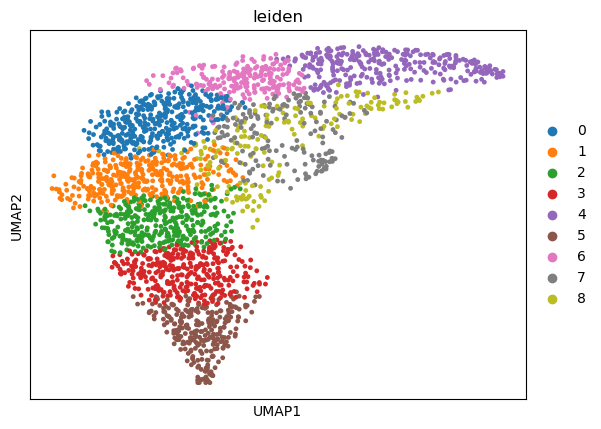

In [8]:
sc.pp.neighbors(adata_rna)
sc.tl.leiden(adata_rna)
sc.tl.umap(adata_rna)

sc.pl.umap(adata_rna, color="leiden", show=False)
plt.savefig("./figures/rna_umap_svg.png", dpi=500)

### Processing surface epitope data

In [9]:
# Load protein count matrix 
X_protein = sc.read_hdf("./raw_data/GSM6578062_human_tonsil_SVG.h5", key="X_protein")
adata_prot = ad.AnnData(X=X_protein.X)

adata_prot.obs_names = cell
adata_prot.var_names = prot
adata_prot.obsm["pos"] = pos

adata_prot.X

array([[  0,   0,  15, ...,  20,  65, 253],
       [  0,   0,  32, ...,   7,  61, 257],
       [  2,   0,  21, ...,  18,  72, 260],
       ...,
       [  0,   0,   2, ...,   3,  19,  76],
       [  0,   0,   8, ...,  12,  75, 159],
       [  0,   0,  20, ...,   8,  76, 195]],
      shape=(2492, 283), dtype=int32)

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/scanpy/neighbors/__init__.py:577: UserWarning: You’re trying to run this on 283 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  x = _choose_representation(self._adata, use_rep=use_rep, n_pcs=n_pcs)


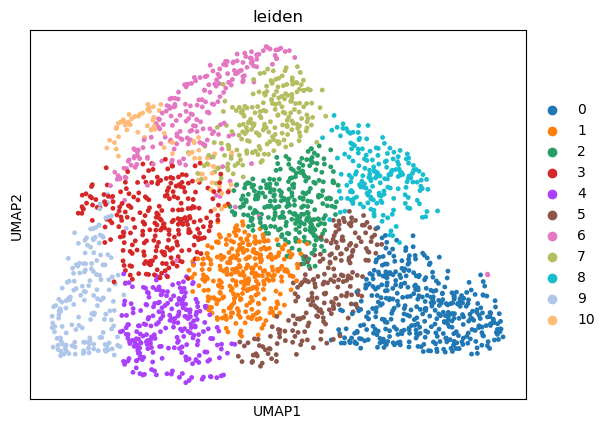

In [10]:
sc.pp.neighbors(adata_prot)
sc.tl.leiden(adata_prot)
sc.tl.umap(adata_prot)

sc.pl.umap(adata_prot, color="leiden", show=False)
plt.savefig("./figures/prot_umap_svg.png", dpi=500)

### Processing mudata

In [11]:
# Build the mudata
mdata = md.MuData({"RNA": adata_rna, "Protein": adata_prot})
mdata

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


MuData object with n_obs × n_vars = 2492 × 1267
  2 modalities
    RNA:	2492 x 984
      obs:	'leiden'
      uns:	'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
      obsm:	'pos', 'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'pca', 'neighbors', 'leiden', 'umap', 'leiden_colors'
      obsm:	'pos', 'X_pca', 'X_umap'
      varm:	'PCs'
      obsp:	'distances', 'connectivities'

In [12]:
mdata.write_h5mu("./tonsil_pp_svg.h5mu")

/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/ubc/cs/research/beaver/projects/carlos/conda_envs/totalvi/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


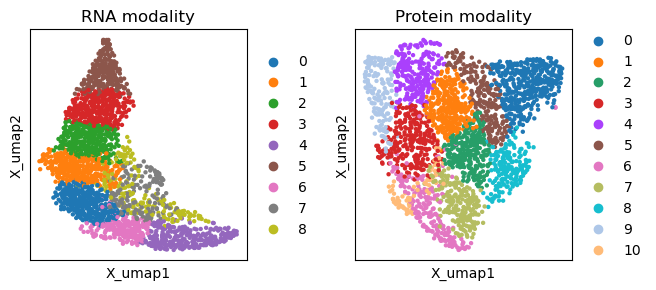

In [29]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), gridspec_kw={"wspace": 0.5})

sc.pl.embedding(mdata["RNA"], basis="X_umap", color="leiden", s=40, show=False, ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("RNA modality")

sc.pl.embedding(mdata["Protein"], basis="X_umap", color="leiden", s=40, show=False, ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title("Protein modality")

plt.savefig("./figures/modality_umap_svg.png", dpi=500)

### Visualize RNA & protein clusters in (x,y)

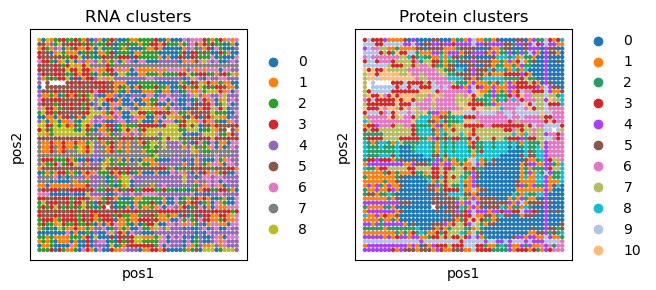

In [28]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3), gridspec_kw={"wspace": 0.5})

sc.pl.embedding(mdata["RNA"], basis="pos", color="leiden", s=40, show=False, ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("RNA clusters")

sc.pl.embedding(mdata["Protein"], basis="pos", color="leiden", s=40, show=False, ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title("Protein clusters")

plt.savefig("./figures/modality_clusters_spatial_svg.png", dpi=500)

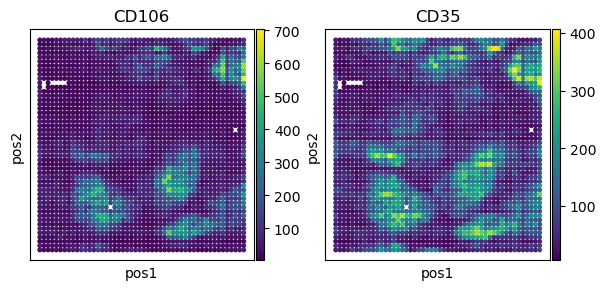

In [16]:
# From OG paper: markers for clusters 2/5
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD106.TCACAGTTCCTTGGA", s=50, show=False, ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("CD106")

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD35.ACTTCCGTCGATCTT", s=50, show=False, ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title("CD35")

plt.savefig("./figures/GC_markers_spatial_svg.png", dpi=400, bbox_inches="tight")

In [50]:
mdata["Protein"].var[mdata["Protein"].var.index.str.contains("CD49a")]

""
CD49a.ACTGATGGACTCAGA


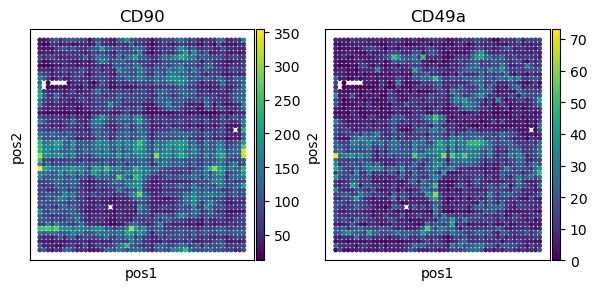

In [52]:
# Extracellular / absent in GC
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(7, 3))

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD90..Thy1..GCATTGTACGATTCA", s=50, show=False, ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("CD90")

sc.pl.embedding(mdata["Protein"], basis="pos", color="CD49a.ACTGATGGACTCAGA", s=50, show=False, ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title("CD49a")
plt.savefig("./figures/EC_markers_spatial_svg.png", dpi=400, bbox_inches="tight")

In [55]:
mdata["RNA"].var

""
NMNAT1
SFN
S100A9
MEIS1.AS1
IGKC
...
CXCL13
SETD5
GBA2
SDHD
